# Лабораторная работа №1. Настройка окружения и разведочный анализ данных.

## Цель работы

Подготовить структуру проекта и провести разведочный анализ данных. Результаты первой лабораторной работы будут использоваться в дальнейшем цикле работ.

# Выполнение работы

Для дальнейшей работы был выбран датасет :
    Car Price prediction

### 12 Разведочный анализ данных датасета Car prediction

#### 1. Импорт библиотек

In [70]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import pickle

#### 2. Загрузка данных

In [84]:
df = pd.read_csv('/home/mainuser/mf_project/data/car data.csv')

print("Размер данных:", df.shape)  
print("Столбцы:", list(df.columns))  
print("\nПервые 10 строк:")

df.head(10)

Размер данных: (301, 9)
Столбцы: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Первые 10 строк:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


#### Основная информация о данных

Метод df.info(show_counts=True) 

Показывает главную информацию о таблице (DataFrame) и заставляет ее выдать точное количество заполненных ячеек.

Параметр (show_counts=True) управляет показом непустых (заполненных) значений.

In [85]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Преобразование текстовых данных в специальный тип категорий

In [86]:
df['Car_Name'] = df['Car_Name'].astype('category')
df['Fuel_Type'] = df['Fuel_Type'].astype('category')
df['Selling_type'] = df['Selling_type'].astype('category')
df['Transmission'] = df['Transmission'].astype('category')

Преобразование числовых признаков в специальный тип - числа целые и с плавающей запятой

In [87]:
df['Owner'] = df['Owner'].astype('int8')

df['Year'] = df['Year'].astype('float32')
df['Selling_Price'] = df['Selling_Price'].astype('float32')
df['Present_Price'] = df['Present_Price'].astype('float32')
df['Driven_kms'] = df['Driven_kms'].astype('float32')

df.describe() 

Метод  для быстрого получения описательной статистики по числовым столбцам.

In [88]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627930,4.661296,7.628471,36947.207031,0.043189
std,2.891554,5.082811,8.642585,38886.882812,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.599998,500000.000000,3.000000


Преобразование категориальных признаков  в список

In [89]:
cat_features = df.select_dtypes(include=['category']).columns.to_list()
cat_features

['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']

Преобразование числовых признаков в список 

In [90]:
num_features = df.select_dtypes(include=['number']).columns.to_list()
num_features

['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']

#### 4. Проверка на пропуски и дубликаты

In [ ]:
print("Пропущенные значения в каждом столбце:")
print(df.isnull().sum())  

duplicates = df.duplicated().sum()  
print(f"\nКоличество дубликатов: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()  
    print(f"Удалили {duplicates} дубликатов")
else:
    print("Дубликатов нет")

Пропущенные значения в каждом столбце:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Количество дубликатов: 2
Удалили 2 дубликатов


Подсчет уникальных значений, содержащихся в каждом столбце таблицы.

In [92]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

Car_Name - numer of unique = 98
Fuel_Type - numer of unique = 3
Selling_type - numer of unique = 2
Transmission - numer of unique = 2


In [93]:
for col in cat_features:
    print(f'Unique categories in {col}: {df[col].value_counts()}')

Unique categories in Car_Name: Car_Name
city             26
corolla altis    16
verna            14
brio             10
fortuner         10
                 ..
ignis             1
omni              1
land cruiser      1
s cross           1
vitara brezza     1
Name: count, Length: 98, dtype: int64
Unique categories in Fuel_Type: Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Unique categories in Selling_type: Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64
Unique categories in Transmission: Transmission
Manual       260
Automatic     39
Name: count, dtype: int64



Вывод: датасет состоит из 301 строки и 9 столбцов, после удаления дубликатов получается 299 строк.
Пропущенных значений невыявлено. 

Целевой переменной является Selling_Price. 
Минимум 0.10, а максимум 35. Среднее значение равно 4.66, а медиана 3.60.

#### 5. Очистка данных и сохранение в новый файл

In [94]:
df = df.loc[df['Year'] > 0]
df = df.query('Selling_Price > 0')
df = df.query('Present_Price > 0')
df = df.query('Driven_kms >= 0')
df = df.query('Owner >= 0')

In [95]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       299 non-null    category
 1   Year           299 non-null    float32 
 2   Selling_Price  299 non-null    float32 
 3   Present_Price  299 non-null    float32 
 4   Driven_kms     299 non-null    float32 
 5   Fuel_Type      299 non-null    category
 6   Selling_type   299 non-null    category
 7   Transmission   299 non-null    category
 8   Owner          299 non-null    int8    
dtypes: category(4), float32(4), int8(1)
memory usage: 11.7 KB


In [96]:
df['Car_Age'] = 2026 - df['Year'] 

print("Была добавлена 1 новая переменная")
print("Размер DataFrame после очистки:", df.shape)

print("\nПервые 5 строк с новым признаком:")
df[['Car_Name', 'Year', 'Car_Age']].head()

Была добавлена 1 новая переменная
Размер DataFrame после очистки: (299, 10)

Первые 5 строк с новым признаком:


,Car_Name,Year,Car_Age
0,ritz,2014.0,12.0
1,sx4,2013.0,13.0
2,ciaz,2017.0,9.0
3,wagon r,2011.0,15.0
4,swift,2014.0,12.0


Вывод: Был установлен фильтр: на отрицательные и в некоторых случаях на нулевые значения. После очистки невалидных данных выявлено не было. Также была добавлена новая переменная "Срок службы автомобиля". Других фильтров установлено не было.

#### 5. Анализ признаков для модели

In [101]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

График распределения цен машины 

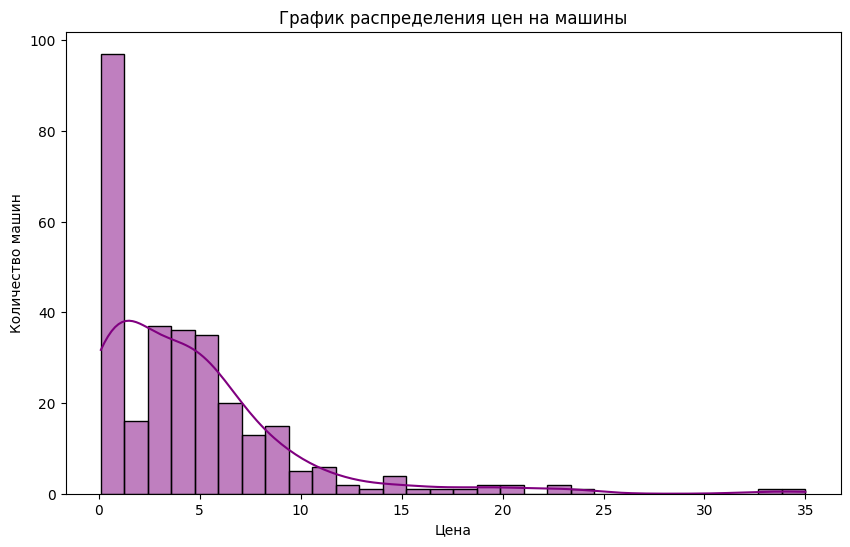

In [103]:
plt.figure(figsize=(10, 6))  
sns.histplot(df['Selling_Price'], kde=True, bins=30, color='purple')  
plt.title('График распределения цен на машины')  
plt.xlabel('Цена')  
plt.ylabel('Количество машин')  
plt.savefig('цены_машин.png') 
plt.show()  

Вывод: Большинство машин имеет стоимость ниже или равную 10 lakhs, помимо этого присутствуют и дорогие варианты машин.

График цена и год выпуска

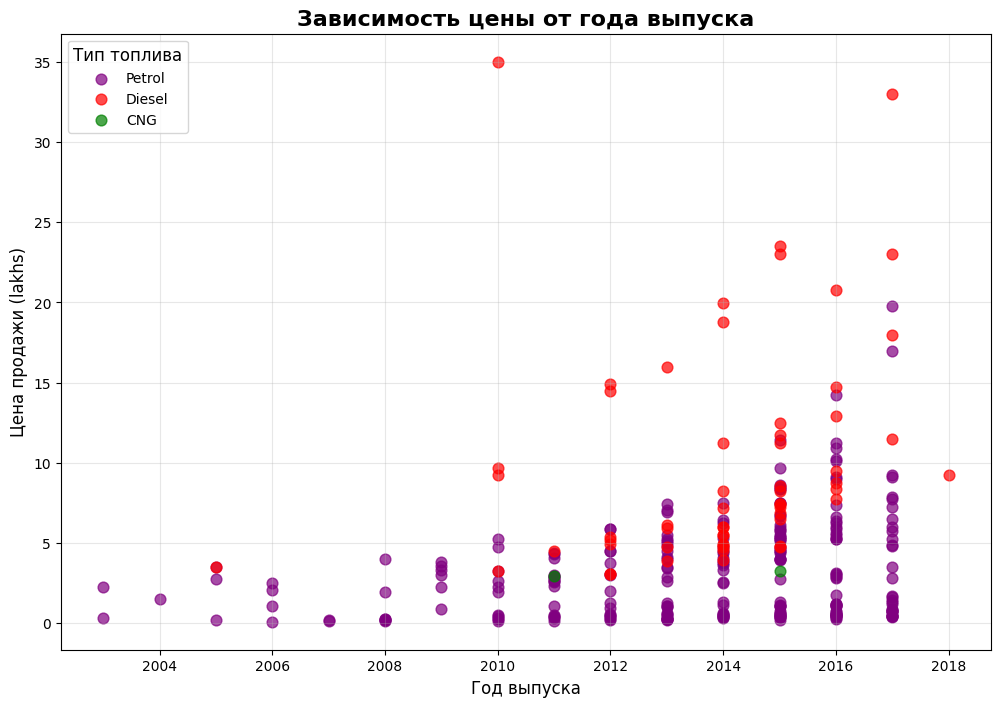

In [107]:
colors = {'Petrol': 'purple', 'Diesel': 'red', 'CNG': 'green'}

plt.figure(figsize=(12, 8))

for fuel_type in df['Fuel_Type'].unique():
    subset = df[df['Fuel_Type'] == fuel_type]
    plt.scatter(subset['Year'], subset['Selling_Price'],
                label=fuel_type, alpha=0.7, s=60,
                color=colors[fuel_type])

plt.title('Зависимость цены от года выпуска', fontsize=16, fontweight='bold')
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Цена продажи (lakhs)', fontsize=12)
plt.legend(title='Тип топлива', title_fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig('цена_и_год.png')
plt.show()

Вывод: Исходя из графика можно сделать вывод, что машины имеющие дизельный двигатель внутреннего сгорания стоят дороже, нежели машины на природном газе и машины на бензине. Также по графику видно, что чем новее машина, тем она дороже"

График корреляционная матрица

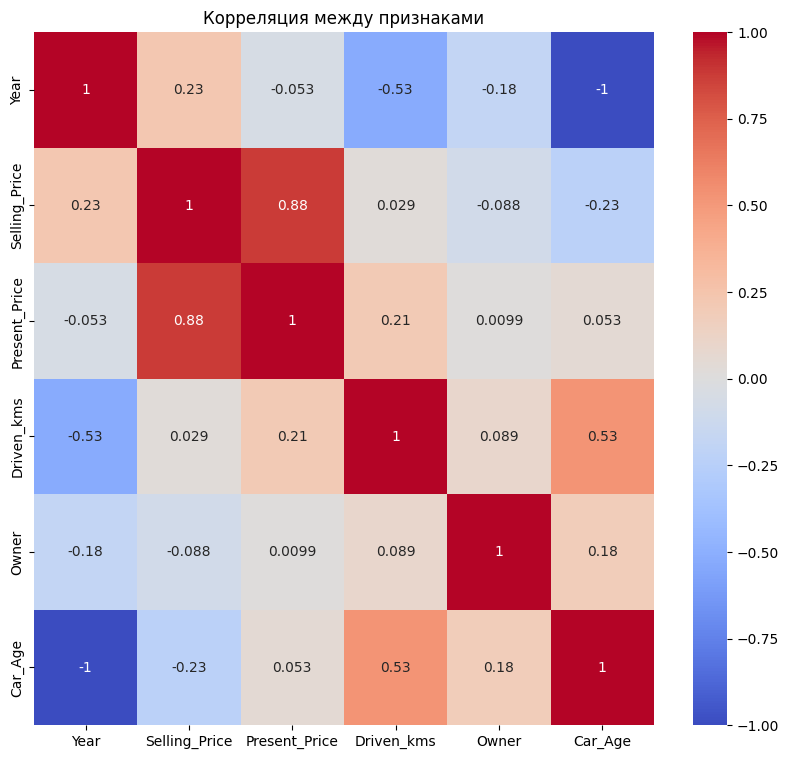

In [109]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 9))  

sns.heatmap(numeric_df.corr(), 
            annot=True,     
            cmap='coolwarm', 
            center=0)       
plt.title('Корреляция между признаками')  
plt.savefig('корреляционная_матрица.png')  
plt.show()  

Вывод: 

График цен по типам топлива

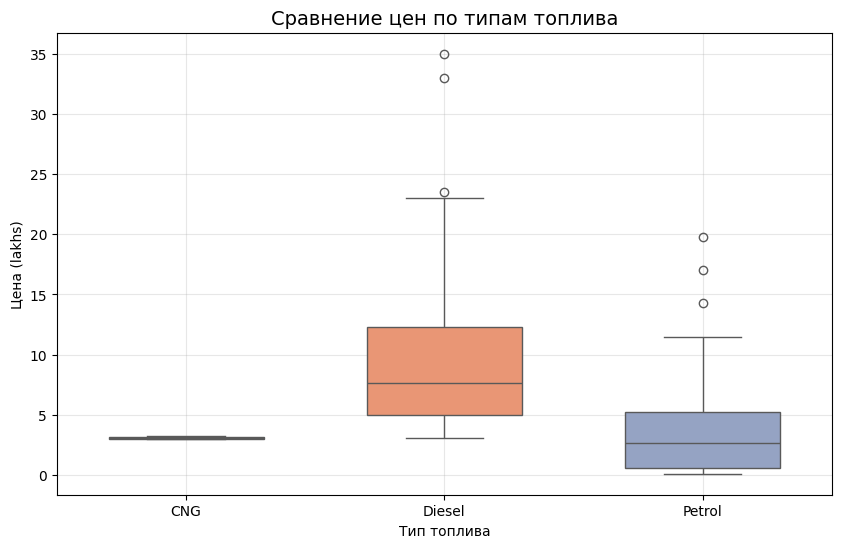

In [110]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, 
            hue='Fuel_Type', 
            legend=False,     
            width=0.6,
            palette='Set2')

plt.title('Сравнение цен по типам топлива', fontsize=14)
plt.xlabel('Тип топлива')
plt.ylabel('Цена (lakhs)')
plt.grid(True, alpha=0.3)

plt.savefig('цена_по_типам_топлива.png')
plt.show()

Вывод:

График цена от пробега

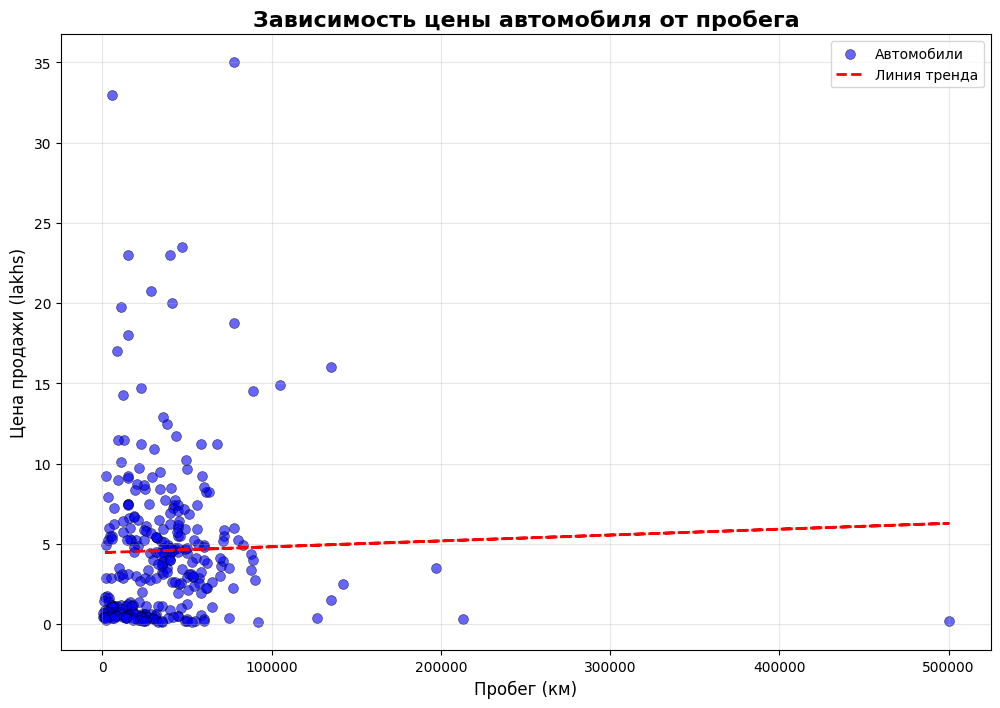

Коэффициент корреляции: 0.029


In [112]:
plt.figure(figsize=(12, 8))

plt.scatter(df['Driven_kms'], df['Selling_Price'],
            alpha=0.6,
            s=50,
            color='blue',
            edgecolors='black',
            linewidth=0.5,
            label='Автомобили')

z = np.polyfit(df['Driven_kms'], df['Selling_Price'], 1)
p = np.poly1d(z)
plt.plot(df['Driven_kms'], p(df['Driven_kms']),
         color='red',
         linewidth=2,
         linestyle='--',
         label='Линия тренда')

plt.title('Зависимость цены автомобиля от пробега', fontsize=16, fontweight='bold')
plt.xlabel('Пробег (км)', fontsize=12)
plt.ylabel('Цена продажи (lakhs)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('цена_от_пробега.png')
plt.show()


correlation = df['Selling_Price'].corr(df['Driven_kms'])
print(f"Коэффициент корреляции: {correlation:.3f}")


Вывод: Из графика видно, что машины, которые имеют минимальный пробег, имеют наибольшую цену. А на машины, у которых пробег начинает превышать за 100.000 км, цена снижается.